# Setup

In [1]:
import json
import os

import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

## Random Topic

In [2]:
file_df = pd.DataFrame(os.listdir("../data/toxic_and_baseline_random_magistral/"), columns=["Path"])
# remove '.ipynb_checkpoints'"
print(file_df.shape)
file_df = file_df.query("Path != '.ipynb_checkpoints'", engine="python")
print(file_df.shape)

(24836, 1)
(24835, 1)


In [3]:
file_df["discussion"] = file_df["Path"].str.split("_round_").apply(lambda x: int(x[0].split("_")[1]))

In [4]:
file_df["round"] = file_df["Path"].str.split("_for_").apply(lambda x: int(x[0].split("_round_")[1]))

In [5]:
file_df["toxicity_level"] = file_df["Path"].str.split("_level_").apply(lambda x: x[1].split(".json")[0])

In [6]:
file_df["max_round_per_discussion"] = file_df.groupby(["toxicity_level", "discussion"])["round"].transform("max")

In [7]:
file_df = file_df.query("round == max_round_per_discussion")

In [8]:
rounds_of_convergence = []
for path in file_df["Path"]:
    # if not ready yet, skip the final discussion that has not been finished
    #if "discussion_62" in path:
    #    rounds_of_convergence.append((None, None))
    #    continue

    with open(f'../data/toxic_and_baseline_random_magistral/' + path, 'r') as fp:
        debate = json.load(fp)

    # *2 because of pairs
    # +jx because it might be counterargument of round
    # +1 because there has been a previous round
    unfold_history = [
        ((ix)*(2) + jx + 1, content["next_answer"], content["agent"].split("_")[0]) 
        for ix, (name, contents) in enumerate(debate["discussion_history"].items()) 
        if name.startswith('Round') for 
        jx, content in enumerate(contents)
    ]

    rounds_until_convergence_by_discussion = pd.DataFrame(unfold_history, columns=["round", "argument", "procon"])\
        .query("argument == 'convinced'")\
        .sort_values("round", ascending=True).assign(toxic_agent=debate["pro_or_con_toxic"]).head(1)
    
    if len(rounds_until_convergence_by_discussion) > 0:
        rounds_of_convergence.append(
            (
                rounds_until_convergence_by_discussion["round"].iloc[0],
                rounds_until_convergence_by_discussion["procon"].iloc[0] + " has been convinced",
                rounds_until_convergence_by_discussion["toxic_agent"].iloc[0] + " has toxic behaviour",
            )
        )
        continue

    unfold_history = [
        ((ix)*(2) +2, content['state of discussion']) 
        if "state of discussion" in content.keys() else 
        ((ix)*(2) +2, content['state_of_discussion']) 
        for ix, (name, content) in enumerate(debate["moderators_history"].items()) 
        if name.startswith('after_')
    ]
    rounds_until_convergence_by_moderator = pd.DataFrame(unfold_history, columns=["round", "status"])\
        .query("status == 'agents are in agreement'")\
        .sort_values("round", ascending=True).assign(toxic_agent=debate["pro_or_con_toxic"]).head(1)

    if len(rounds_until_convergence_by_moderator) > 0:
        rounds_of_convergence.append(
            (
                rounds_until_convergence_by_moderator["round"].iloc[0],
                "moderator detected alignment",
                rounds_until_convergence_by_moderator["toxic_agent"].iloc[0] + " has toxic behaviour",
            )
        )
        continue
    
    rounds_of_convergence.append(
        (None, None, None)
    )
    print("Oh")
        

In [9]:
file_df[["rounds_to_convergence", "reason_for_convergence", "which_agent_is_toxic"]] = rounds_of_convergence

In [10]:
file_df = file_df.query("rounds_to_convergence.notnull() & toxicity_level.isin(['mild', 'moderate', 'no', 'heavy'])", engine="python")

In [11]:
conversion_vc = file_df.groupby("toxicity_level")["rounds_to_convergence"].value_counts(dropna=False).unstack().T
conversion_vc

toxicity_level,heavy,mild,moderate,no
rounds_to_convergence,,,,
3,18.0,20.0,27.0,32.0
4,18.0,17.0,15.0,61.0
5,16.0,22.0,20.0,35.0
6,43.0,43.0,57.0,171.0
7,27.0,24.0,18.0,51.0
...,...,...,...,...
95,1.0,NaN,NaN,NaN
96,1.0,NaN,NaN,NaN
103,1.0,NaN,NaN,NaN


In [12]:
conversion_mean = file_df.groupby("toxicity_level")["rounds_to_convergence"].agg(["mean", "size"])
conversion_mean.columns = ["average conversion", "# debates"]
conversion_mean

,average conversion,# debates
toxicity_level,,
heavy,20.108,1000
mild,15.125,1000
moderate,13.118,1000
no,8.282,1000


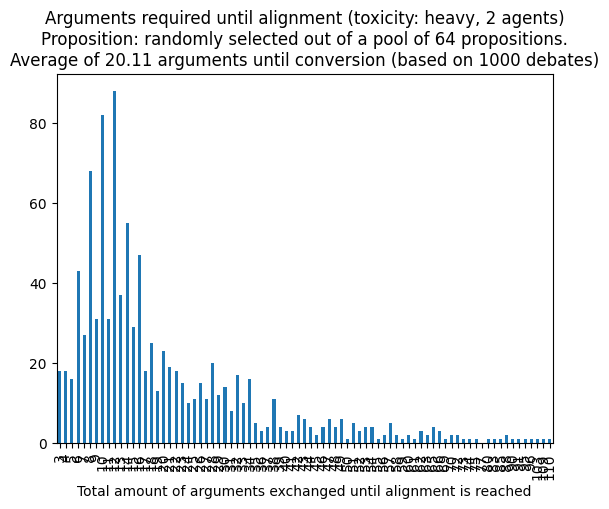

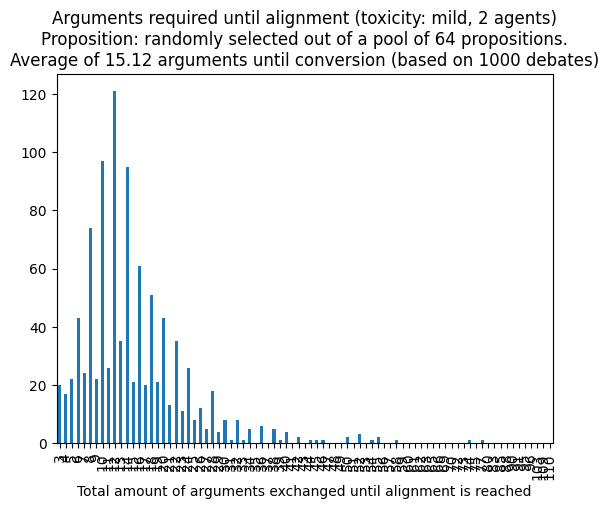

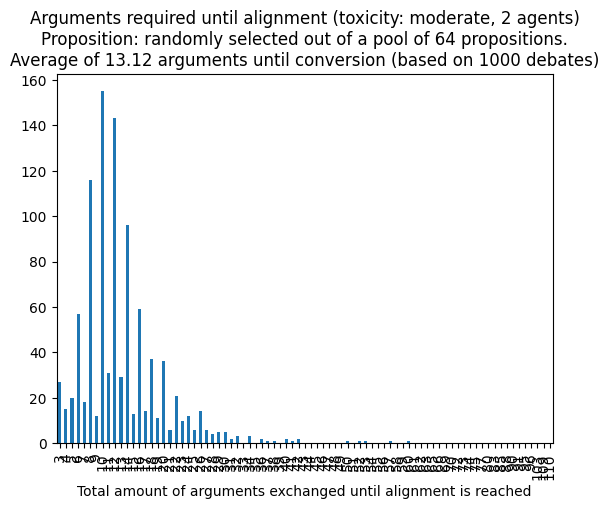

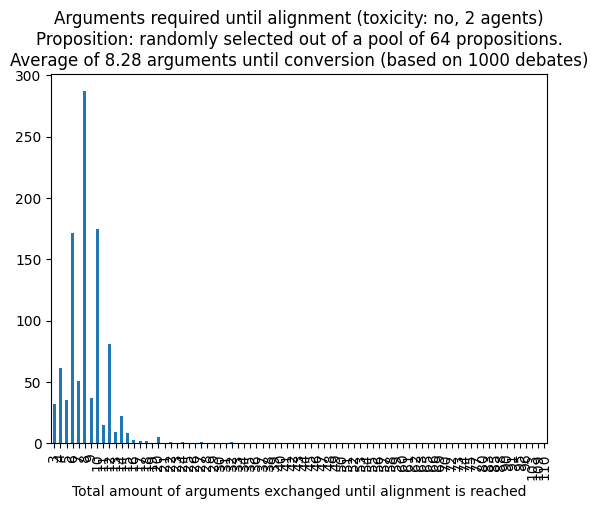

In [13]:
for toxicity_level in conversion_vc.columns:
    (conversion_vc[toxicity_level]).sort_index()\
    .plot(
        kind="bar",
        title=(
            f"Arguments required until alignment (toxicity: {toxicity_level}, 2 agents)\n"
            f"Proposition: randomly selected out of a pool of 64 propositions.\nAverage of {conversion_mean.loc[toxicity_level, 'average conversion']:.2f} "
            f"arguments until conversion (based on {int(conversion_mean.loc[toxicity_level, '# debates'])} debates)"
        ),
        xlabel="Total amount of arguments exchanged until alignment is reached"
    )
    plt.show();

In [26]:
print(conversion_vc.index.max())


110


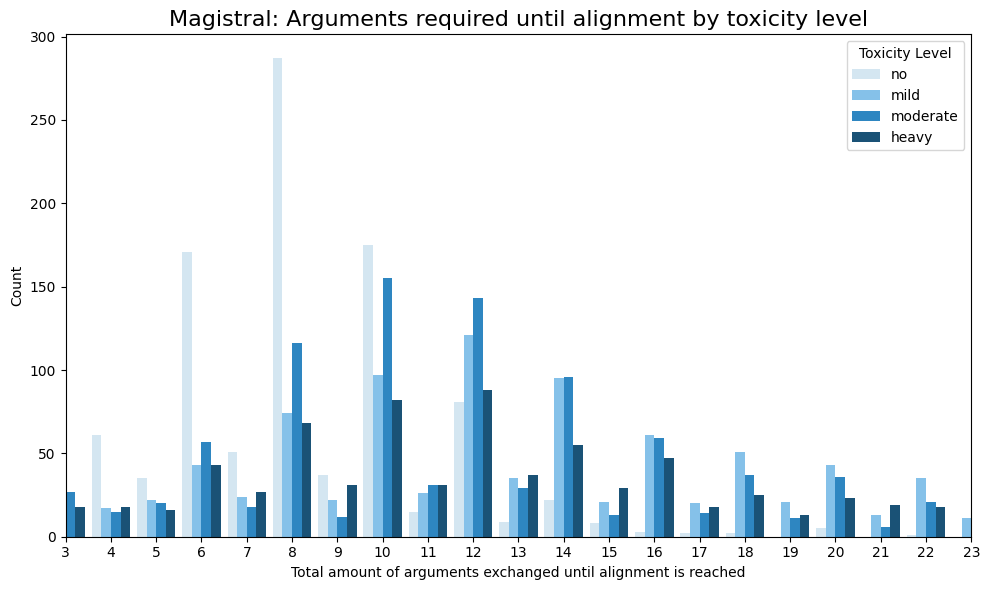

In [45]:
toxicity_order = ["no", "mild", "moderate", "heavy"]
colors = ['#d4e6f1', '#85c1e9', '#2e86c1', '#1a5276']


fig, ax = plt.subplots(figsize=(10, 6))

# plot each toxicity level as a grouped bar
conversion_vc[toxicity_order].sort_index().plot(
    kind="bar",
    ax=ax,
    color=colors,
    width=0.85

)

ax.set_title(
    "Magistral: Arguments required until alignment by toxicity level",
    fontsize=16
)
ax.set_xlim(0, 20)
ax.set_xlabel("Total amount of arguments exchanged until alignment is reached")
ax.set_ylabel("Count")
ax.legend(title="Toxicity Level")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("toxicity_comparison_magistral.png", bbox_inches='tight', dpi=150)
plt.show()

In [15]:
file_df.to_csv(
    f"../data/evaluation mad/convergence_of_{len(file_df)}_toxic_random_discussions_magistral.csv",
    index=False
)

In [16]:
conversion_mean["average conversion"] / conversion_mean["average conversion"].loc["no"]

toxicity_level
heavy       2.427916
mild         1.82625
moderate    1.583917
no               1.0
Name: average conversion, dtype: object

In [17]:
file_df.groupby("toxicity_level")["rounds_to_convergence"].agg(["mean", "var", "size"])

,mean,var,size
toxicity_level,,,
heavy,20.108,259.670006,1000
mild,15.125,74.07545,1000
moderate,13.118,47.851928,1000
no,8.282,8.995471,1000


In [18]:
baseline = file_df.query("toxicity_level == 'no'")["rounds_to_convergence"].tolist()

In [19]:
mild = file_df.query("toxicity_level == 'mild'")["rounds_to_convergence"].tolist()
moderate = file_df.query("toxicity_level == 'moderate'")["rounds_to_convergence"].tolist()

In [20]:
print ("The t-statistic is %.3f and the p-value is %.3f (Alternative: unequal)." % stats.ttest_ind(
    baseline, mild, equal_var=False))

The t-statistic is -23.742 and the p-value is 0.000 (Alternative: unequal).


In [21]:
print ("The t-statistic is %.3f and the p-value is %.3f (Alternative: unequal)." % stats.ttest_ind(
    baseline, moderate, equal_var=False))

The t-statistic is -20.283 and the p-value is 0.000 (Alternative: unequal).


In [22]:
print ("The t-statistic is %.3f and the p-value is %.3f  (Alternative: unequal)." % stats.ttest_ind(
    moderate, mild, equal_var=False))

The t-statistic is -5.748 and the p-value is 0.000  (Alternative: unequal).


In [23]:
print (
    "The t-statistic is %.3f and the p-value is %.3f  (Alternative: less)." % stats.ttest_ind(
        mild, moderate, equal_var=False, alternative="less")
)

The t-statistic is 5.748 and the p-value is 1.000  (Alternative: less).


In [24]:
print (
    "The t-statistic is %.3f and the p-value is %.3f  (Alternative: less)." % stats.ttest_ind(
        baseline, moderate, equal_var=False, alternative="less")
)

The t-statistic is -20.283 and the p-value is 0.000  (Alternative: less).


In [25]:
print (
    "The t-statistic is %.3f and the p-value is %.3f  (Alternative: less)." % stats.ttest_ind(
        baseline, mild, equal_var=False, alternative="less")
)

The t-statistic is -23.742 and the p-value is 0.000  (Alternative: less).
